# Notebook 15 — Deep Hedging for Exotic Options under Transaction Costs

This notebook demonstrates:
1. Setting up the `BarrierHedgingEnv` for Down-and-Out Barrier Call options.
2. Formulating boundary-aware features including the log-barrier-distance.
3. Training the LSTM policy under proportional transaction costs.
4. Visualizing learned rebalancing bands (hedging corridors) around the barrier.

In [1]:
import os
import sys

# Ensure src is in python path
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "src") if os.path.basename(os.getcwd()) == "notebooks"
                else os.path.join(os.getcwd(), "src"))

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from hedging.deep_hedging import HedgingPolicy, train_deep_hedger
from hedging.barrier_hedging import BarrierHedgingEnv

plt.rcParams.update({
    "figure.dpi": 100,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 11,
    "font.family": "serif",
})

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)



Using device: cuda


## 1. Simulate Paths for Barrier Option Environment

We simulate stock price paths with a negative drift to ensure the barrier gets tested frequently.

In [2]:
def simulate_gbm_paths(S0, mu, sigma, T, steps, N_paths, device="cpu"):
    dt = T / steps
    t_grid = torch.arange(steps + 1, device=device) * dt
    W = torch.randn(N_paths, steps, device=device)
    log_returns = (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * W
    S = S0 * torch.exp(torch.cumsum(log_returns, dim=-1))
    S0_col = torch.full((N_paths, 1), S0, device=device)
    S_full = torch.cat([S0_col, S], dim=-1)
    
    vol = torch.full_like(S_full, sigma)
    H = torch.stack([S_full, vol], dim=-1)
    return H, t_grid

# Config
S0 = 100.0
K = 100.0
barrier = 85.0
T = 0.1
steps = 20
sigma = 0.2
N_paths = 2048

H, t_grid = simulate_gbm_paths(S0=S0, mu=-0.2, sigma=sigma, T=T, steps=steps, N_paths=N_paths, device=device)
print(f"Stock price paths S: {H.shape}")



Stock price paths S: torch.Size([2048, 21, 2])


## 2. Initialize Barrier Hedging Environment and Policy

We set up proportional transaction costs of 1% to encourage the policy to learn no-transaction bands.

In [3]:
cost_coeffs = torch.tensor([0.01, 0.0], device=device)  # 1% transaction costs on stock
env = BarrierHedgingEnv(
    H=H,
    cost_coeffs=cost_coeffs,
    strike=K,
    barrier=barrier,
    expiry=T,
    risk_aversion=1.0,
    risk_measure="quad",
    t_grid=t_grid
)

# Input dim: log(S/K), log(S/B), T-t, active_mask, prev_delta (2) = 6
policy = HedgingPolicy(input_dim=6, hidden_dim=32, output_dim=2).to(device)
print(policy)



HedgingPolicy(
  (lstm_cell): LSTMCell(6, 32)
  (fc): Sequential(
    (0): Linear(in_features=32, out_features=32, bias=True)
    (1): SiLU()
    (2): Linear(in_features=32, out_features=2, bias=True)
  )
)


## 3. Train the Barrier Hedging Policy

We optimize the policy pathwise, tracking the dynamically evaluated payoffs.

Training the barrier hedging policy...
Epoch 01/40 | Loss: 16.458786


Epoch 05/40 | Loss: 11.911452
Epoch 10/40 | Loss: 11.267858
Epoch 15/40 | Loss: 11.352188


Epoch 20/40 | Loss: 11.211210
Epoch 25/40 | Loss: 11.239065
Epoch 30/40 | Loss: 11.207303


Epoch 35/40 | Loss: 11.208704
Epoch 40/40 | Loss: 11.200754


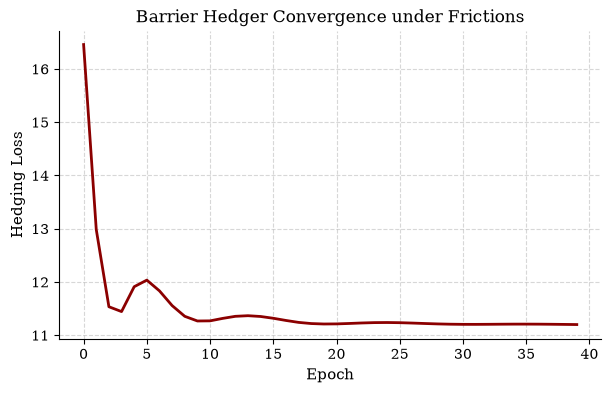

In [4]:
# Custom training loop to handle BarrierHedgingEnv's dynamic payoff
policy.train()
optimizer = torch.optim.Adam(policy.parameters(), lr=5e-3)
losses = []

print("Training the barrier hedging policy...")
for epoch in range(40):
    optimizer.zero_grad()
    
    # Simulate episode and get terminal wealth
    wealth, total_costs, _ = env.simulate_hedging_episode(policy)
    
    # Compute risk loss
    loss = env.compute_loss(wealth)
    
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:02d}/40 | Loss: {loss.item():.6f}")

# Plot loss
plt.figure(figsize=(7, 4))
plt.plot(losses, color="darkred", lw=2)
plt.xlabel("Epoch")
plt.ylabel("Hedging Loss")
plt.title("Barrier Hedger Convergence under Frictions")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()



## 4. Visualize Hedging Corridor / Rebalancing Bands

We map the learned hedge ratio $\delta_t$ as a function of the underlying stock price for different previous positions, showing that the policy remains unchanged within a corridor to save on rebalancing costs.

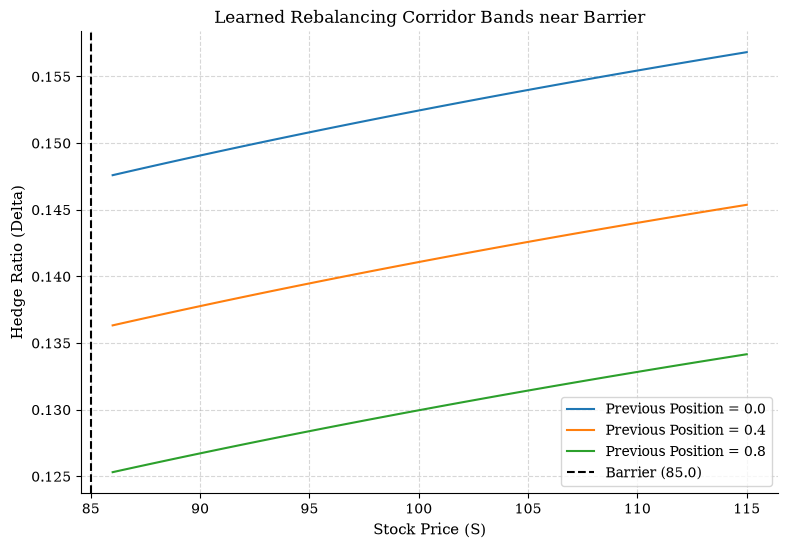

In [5]:
policy.eval()
spots = np.linspace(86, 115, 100)
prev_positions = [0.0, 0.4, 0.8]

plt.figure(figsize=(9, 6))

for prev_pos in prev_positions:
    spots_tensor = torch.tensor(spots, dtype=torch.float32, device=device).unsqueeze(-1)
    log_moneyness = torch.log(spots_tensor / K)
    log_barrier_dist = torch.log(spots_tensor / barrier)
    time_to_exp = torch.full_like(spots_tensor, T)
    active_mask = torch.ones_like(spots_tensor)
    prev_pos_tensor = torch.full_like(spots_tensor, prev_pos)
    dummy_vol_pos = torch.zeros_like(spots_tensor)
    
    # Prepare features
    state = torch.cat([log_moneyness, log_barrier_dist, time_to_exp, active_mask, prev_pos_tensor, dummy_vol_pos], dim=-1)
    
    with torch.no_grad():
        delta, _ = policy(state)
        delta_stock = delta[:, 0].cpu().numpy()
        
    plt.plot(spots, delta_stock, label=f"Previous Position = {prev_pos}")

plt.axvline(barrier, color="black", linestyle="--", label="Barrier (85.0)")
plt.xlabel("Stock Price (S)")
plt.ylabel("Hedge Ratio (Delta)")
plt.title("Learned Rebalancing Corridor Bands near Barrier")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

